In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

In [9]:
df = pd.read_csv("student_data1.csv")
print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())

Dataset Shape: (10000, 20)
   Gender  Age  Semester Branch Difficulty_Level  Attendance (%)  \
0    Male   23         6    CSE             Hard       52.945086   
1  Female   19         2    CSE             Easy             NaN   
2    Male   18         2  Civil             Easy       74.524728   
3    Male   18         3    CSE         Moderate       67.977237   
4  Female   22         5    CSE             Easy       61.048711   

   Midterm_Score  Assignments_Avg  Quizzes_Avg  Participation_Score  \
0          42.60            47.20        27.25             4.970665   
1          62.31            49.93        40.11             5.159091   
2          61.30            47.75        48.17             3.014923   
3          52.35            45.15        28.36             4.303704   
4          56.86            38.82        34.48             4.877667   

   Projects_Score  Study_Hours_per_Week Internet_Access_at_Home  \
0           45.28             27.702422                     Yes   
1  

In [10]:
X = df.drop(["Final_Score","Grade","Pass/Fail"], axis=1)
y = df["Final_Score"]

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

X = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Preprocessing completed for XGBoost")

Preprocessing completed for XGBoost


In [11]:
import numpy as np


df["Total_Academic_Score"] = (
    df["Midterm_Score"] +
    df["Assignments_Avg"] +
    df["Quizzes_Avg"] +
    df["Projects_Score"]
)


df["Attendance_Performance_Index"] = (
    df["Attendance (%)"] * df["Participation_Score"]
)

df["Stress_Sleep_Ratio"] = df["Stress_Level"] / (df["Sleep_Hours_per_Night"] + 1)

df["Academic_Consistency"] = (
    df[["Midterm_Score","Assignments_Avg","Quizzes_Avg","Projects_Score"]]
    .std(axis=1)
)


print("Feature Engineering Completed")

Feature Engineering Completed


In [12]:
X = df.drop(["Final_Score","Grade","Pass/Fail"], axis=1)
y = df["Final_Score"]

In [13]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

X = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Preprocessing completed for XGBoost")

Preprocessing completed for XGBoost


In [14]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

best_xgb_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("XGBoost model trained successfully")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
XGBoost model trained successfully


R2 Score: 0.9155305380533076
MAE: 4.120023811545849
MSE: 26.536628144385222
RMSE: 5.151371481885695


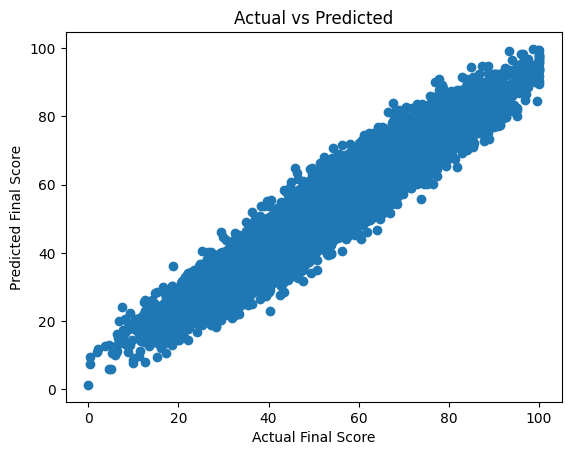

In [15]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

y_pred = best_xgb_model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

plt.figure()
plt.scatter(y, y_pred)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted")
plt.show()